# ExpoMF Model for Coat Shopping Dataset
## Exposure Matrix Factorization for Recommendation System

This notebook implements ExpoMF (Exposure Matrix Factorization) for the Coat shopping dataset, explicitly modeling exposure vs preference.


In [29]:
# =========
# Load file
# =========
import pandas as pd
import numpy as np

# You can choose which dataset to use:
# Option 1: user.txt (largest dataset - 311k interactions)
# Option 2: random.txt (54k interactions)
# Option 3: sampling_data.txt (24k interactions)

# Coat dataset (CSV). Use absolute path to avoid path issues.
data_file = r"C:\Users\prana\OneDrive\Desktop\thesis\exposure bias\pranathi\data\coat_data\coat_data\coat\train.csv"

# Load the data (csv already has header)
ratings = pd.read_csv(data_file, header=0)

print("Data loaded successfully!")
print(f"Total interactions: {len(ratings)}")


Data loaded successfully!
Total interactions: 6960


In [30]:
# =========
# Data info
# =========
print("Dataset shape:", ratings.shape)
print("\nFirst few rows:")
print(ratings.head(10))

print("\nData types:")
print(ratings.dtypes)

print("\nBasic statistics:")
print(ratings.describe())

print("\n" + "="*50)
print("Dataset Summary:")
print("="*50)
print(f"Unique users: {ratings['userId'].nunique()}")
print(f"Unique items: {ratings['itemId'].nunique()}")
print(f"Total interactions: {len(ratings)}")

print("\nRating distribution:")
print(ratings['rating'].value_counts().sort_index())

# Average ratings
user_avg = ratings.groupby('userId')['rating'].mean()
item_avg = ratings.groupby('itemId')['rating'].mean()

print(f"\nAverage rating per user: {user_avg.mean():.3f}")
print(f"Average rating per item: {item_avg.mean():.3f}")

# Ratings per user
ratings_per_user = ratings.groupby('userId')['rating'].count()
print(f"\nAverage interactions per user: {ratings_per_user.mean():.2f}")
print(f"Min interactions per user: {ratings_per_user.min()}")
print(f"Max interactions per user: {ratings_per_user.max()}")

# Ratings per item
ratings_per_item = ratings.groupby('itemId')['rating'].count()
print(f"\nAverage interactions per item: {ratings_per_item.mean():.2f}")
print(f"Min interactions per item: {ratings_per_item.min()}")
print(f"Max interactions per item: {ratings_per_item.max()}")


Dataset shape: (6960, 3)

First few rows:
   userId  itemId  rating
0       0      72     2.0
1       0     136     2.0
2       0     150     3.0
3       0     171     3.0
4       0     188     3.0
5       0     220     3.0
6       0     227     5.0
7       0     228     4.0
8       0     234     3.0
9       0     235     4.0

Data types:
userId      int64
itemId      int64
rating    float64
dtype: object

Basic statistics:
            userId       itemId       rating
count  6960.000000  6960.000000  6960.000000
mean    144.500000   151.399282     2.611494
std      83.721306    83.732434     1.301368
min       0.000000     0.000000     1.000000
25%      72.000000    90.000000     1.000000
50%     144.500000   139.000000     3.000000
75%     217.000000   233.000000     4.000000
max     289.000000   299.000000     5.000000

Dataset Summary:
Unique users: 290
Unique items: 300
Total interactions: 6960

Rating distribution:
rating
1.0    1901
2.0    1437
3.0    1717
4.0    1275
5.0     630

In [31]:
# =============
# Preprocessing
# =============
from sklearn.preprocessing import MinMaxScaler

# Filter items with minimum number of ratings (to remove very sparse items)
min_item_ratings = 5
item_counts = ratings['itemId'].value_counts()
ratings = ratings[ratings['itemId'].isin(item_counts[item_counts >= min_item_ratings].index)]

print(f"After filtering items with < {min_item_ratings} ratings:")
print(f"Remaining interactions: {len(ratings)}")
print(f"Unique users: {ratings['userId'].nunique()}")
print(f"Unique items: {ratings['itemId'].nunique()}")

# Normalize ratings to 0-1 range
scaler = MinMaxScaler()
ratings['rating'] = scaler.fit_transform(ratings[['rating']])

# Create user and item encodings (map to continuous indices starting from 0)
user_ids = ratings['userId'].unique().tolist()
user2user_encoded = {x: i for i, x in enumerate(user_ids)}
userencoded2user = {i: x for x, i in user2user_encoded.items()}

item_ids = ratings['itemId'].unique().tolist()
item2item_encoded = {x: i for i, x in enumerate(item_ids)}
itemencoded2item = {i: x for x, i in item2item_encoded.items()}

# Apply encoding
ratings['user'] = ratings['userId'].map(user2user_encoded)
ratings['item'] = ratings['itemId'].map(item2item_encoded)

# Get dimensions
num_users = len(user2user_encoded)
num_items = len(item2item_encoded)

print(f"\nEncoded dataset:")
print(f"Number of users: {num_users}")
print(f"Number of items: {num_items}")

# Convert ratings to float32 for better performance
ratings['rating'] = ratings['rating'].values.astype(np.float32)

print("\nPreprocessing complete!")
print(ratings.head())


After filtering items with < 5 ratings:
Remaining interactions: 6960
Unique users: 290
Unique items: 300

Encoded dataset:
Number of users: 290
Number of items: 300

Preprocessing complete!
   userId  itemId  rating  user  item
0       0      72    0.25     0     0
1       0     136    0.25     0     1
2       0     150    0.50     0     2
3       0     171    0.50     0     3
4       0     188    0.50     0     4


In [32]:
# =============================
# User-wise Train-Test split
# =============================
# This ensures each user has representation in both train and test sets

train_rows = []
test_rows = []

for user_id, user_data in ratings.groupby('user'):
    n_items = len(user_data)
    
    # Shuffle user's data
    user_data = user_data.sample(frac=1, random_state=42)
    
    # 80-20 split, but ensure at least 1 sample in each set
    train_size = max(1, int(0.8 * n_items))
    
    train_rows.append(user_data.iloc[:train_size])
    if train_size < n_items:
        test_rows.append(user_data.iloc[train_size:])

train_df = pd.concat(train_rows)
test_df = pd.concat(test_rows) if test_rows else train_df.sample(frac=0.1, random_state=42)

print("Train-Test split complete!")
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Train %: {len(train_df)/(len(train_df)+len(test_df))*100:.1f}%")
print(f"Test %: {len(test_df)/(len(train_df)+len(test_df))*100:.1f}%")


Train-Test split complete!
Train shape: (5510, 5)
Test shape: (1450, 5)
Train %: 79.2%
Test %: 20.8%


In [33]:
# ============================
# Prepare Train/Test Arrays
# ============================
X_train = [train_df['user'].values, train_df['item'].values]
X_test = [test_df['user'].values, test_df['item'].values]

y_train = train_df['rating'].values
y_test = test_df['rating'].values

print("Training data prepared!")
print(f"X_train users shape: {X_train[0].shape}")
print(f"X_train items shape: {X_train[1].shape}")
print(f"y_train shape: {y_train.shape}")
print(f"\nTest data prepared!")
print(f"X_test users shape: {X_test[0].shape}")
print(f"X_test items shape: {X_test[1].shape}")
print(f"y_test shape: {y_test.shape}")


Training data prepared!
X_train users shape: (5510,)
X_train items shape: (5510,)
y_train shape: (5510,)

Test data prepared!
X_test users shape: (1450,)
X_test items shape: (1450,)
y_test shape: (1450,)


## ExpoMF Model Architecture

**Key Components:**
1. **Exposure Model**: Models the probability that user `u` was exposed to item `i`
   - Uses item popularity as a proxy for exposure
   - Can be learned or fixed based on item frequency
   
2. **Preference Model**: Matrix Factorization conditional on exposure
   - User and item embeddings
   - Bias terms
   - Models rating given exposure

3. **Likelihood**: 
   - If exposed: P(rating | exposure) × P(exposure)
   - If not exposed: P(no rating | no exposure) × P(no exposure)


In [34]:
# ===============
# Define ExpoMF Model
# ===============
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Dot, Add, Flatten, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras import backend as K

# Hyperparameters
embedding_size = 32
reg_strength = 0.01  # L2 regularization strength
exposure_reg = 0.001  # Regularization for exposure model

# Estimate initial exposure probabilities based on item popularity
item_counts = train_df['item'].value_counts()
total_interactions = len(train_df)
exposure_probs = (item_counts / total_interactions).to_dict()
min_exposure = 0.01
exposure_probs = {k: max(v, min_exposure) for k, v in exposure_probs.items()}

# Create exposure probability array (for all items)
exposure_probs_array = np.array([exposure_probs.get(i, min_exposure) for i in range(num_items)], dtype=np.float32)

print("Exposure probabilities estimated from item popularity")
print(f"Mean exposure prob: {exposure_probs_array.mean():.4f}")
print(f"Min exposure prob: {exposure_probs_array.min():.4f}")
print(f"Max exposure prob: {exposure_probs_array.max():.4f}")

# Inputs
user_input = Input(shape=(1,), name="user_input")
item_input = Input(shape=(1,), name="item_input")

# Preference model (MF)
user_embedding = Embedding(num_users, embedding_size, embeddings_initializer="he_normal",
                           embeddings_regularizer=l2(reg_strength), name="user_embedding")(user_input)
item_embedding = Embedding(num_items, embedding_size, embeddings_initializer="he_normal",
                           embeddings_regularizer=l2(reg_strength), name="item_embedding")(item_input)
user_vec = Flatten()(user_embedding)
item_vec = Flatten()(item_embedding)
mf_output = Dot(axes=1)([user_vec, item_vec])

user_bias = Embedding(num_users, 1, embeddings_initializer="zeros", name="user_bias")(user_input)
item_bias = Embedding(num_items, 1, embeddings_initializer="zeros", name="item_bias")(item_input)
preference_score = Add()([mf_output, Flatten()(user_bias), Flatten()(item_bias)])
preference_output = Activation('sigmoid', name="preference_output")(preference_score)

# Exposure model
exposure_embedding = Embedding(
    num_items,
    1,
    embeddings_initializer=tf.keras.initializers.Constant(
        np.log(exposure_probs_array / (1 - exposure_probs_array + 1e-8)).reshape(-1, 1)
    ),
    embeddings_regularizer=l2(exposure_reg),
    name="exposure_logit"
)(item_input)
exposure_prob = Activation('sigmoid', name="exposure_prob")(Flatten()(exposure_embedding))

# Model with two outputs so exposure layer remains accessible
model = Model(inputs=[user_input, item_input], outputs=[preference_output, exposure_prob], name="expomf_model")

# Loss: optimize only preference output; exposure output has zero weight
model.compile(
    optimizer='adam',
    loss={'preference_output': lambda y_true, y_pred: K.mean(K.square(y_true - y_pred)),
          'exposure_prob': 'mean_squared_error'},
    loss_weights={'preference_output': 1.0, 'exposure_prob': 0.0},
    metrics={'preference_output': ['mae']}
)

print("\nModel architecture:")
model.summary()


Exposure probabilities estimated from item popularity
Mean exposure prob: 0.0100
Min exposure prob: 0.0100
Max exposure prob: 0.0151

Model architecture:


Model: "expomf_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 32)     │      9,280 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_embedding      │ (None, 1, 32)     │      9,600 │ item_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_10          │ (None, 32)        │          0 │ user_embedding[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_11          │ (None, 32)        │          0 │ item_embedding[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_bias           │ (None, 1, 1)      │        290 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_bias           │ (None, 1, 1)      │        300 │ item_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_2 (Dot)         │ (None, 1)         │          0 │ flatten_10[0][0], │
│                     │                   │            │ flatten_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_12          │ (None, 1)         │          0 │ user_bias[0][0]   │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_13          │ (None, 1)         │          0 │ item_bias[0][0]   │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ exposure_logit      │ (None, 1, 1)      │        300 │ item_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 1)         │          0 │ dot_2[0][0],      │
│                     │                   │            │ flatten_12[0][0], │
│                     │                   │            │ flatten_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_14          │ (None, 1)         │          0 │ exposure_logit[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preference_output   │ (None, 1)         │          0 │ add_2[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ exposure_prob       │ (None, 1)         │          0 │ flatten_14[0][0]  │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 19,770 (77.23 KB)

 Trainable params: 19,770 (77.23 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# ==============
# Train Model
# ==============

# Callbacks for better training
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("expomf_pranathi_best_model.keras", save_best_only=True)
]

# Train the model
history = model.fit(
    X_train,
    {'preference_output': y_train, 'exposure_prob': np.zeros_like(y_train)},
    validation_data=(X_test, {'preference_output': y_test, 'exposure_prob': np.zeros_like(y_test)}),
    epochs=20,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete!")


Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - exposure_prob_loss: 1.0432e-04 - loss: 7.4716 - preference_output_loss: 0.1147 - preference_output_mae: 0.2787 - val_exposure_prob_loss: 1.0484e-04 - val_loss: 7.2043 - val_preference_output_loss: 0.1149 - val_preference_output_mae: 0.2843
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - exposure_prob_loss: 1.0763e-04 - loss: 7.1047 - preference_output_loss: 0.1127 - preference_output_mae: 0.2761 

c:\Users\prana\miniconda3\envs\ncf_env\lib\site-packages\keras\src\saving\serialization_lib.py:405: UserWarning: The object being serialized includes a `lambda`. This is unsafe. In order to reload the object, you will have to pass `safe_mode=False` to the loading function. Please avoid using `lambda` in the future, and use named Python functions instead. This is the `lambda` being serialized:     loss={'preference_output': lambda y_true, y_pred: K.mean(K.square(y_true - y_pred)),
          'exposure_prob': 'mean_squared_error'},

  return {key: serialize_keras_object(value) for key, value in obj.items()}


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - exposure_prob_loss: 1.0896e-04 - loss: 7.0179 - preference_output_loss: 0.1128 - preference_output_mae: 0.2763 - val_exposure_prob_loss: 1.0950e-04 - val_loss: 6.8344 - val_preference_output_loss: 0.1136 - val_preference_output_mae: 0.2829
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - exposure_prob_loss: 1.1386e-04 - loss: 6.7050 - preference_output_loss: 0.1107 - preference_output_mae: 0.2746 - val_exposure_prob_loss: 1.1435e-04 - val_loss: 6.5786 - val_preference_output_loss: 0.1123 - val_preference_output_mae: 0.2817
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - exposure_prob_loss: 1.1877e-04 - loss: 6.4858 - preference_output_loss: 0.1095 - preference_output_mae: 0.2732 - val_exposure_prob_loss: 1.1941e-04 - val_loss: 6.3960 - val_preference_output_loss: 0.1111 - val_preference_output_mae: 0.2807
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - exposure_prob_loss: 1.2407e-04 - loss: 6.3263 - preference_output_loss: 0.1076 - p

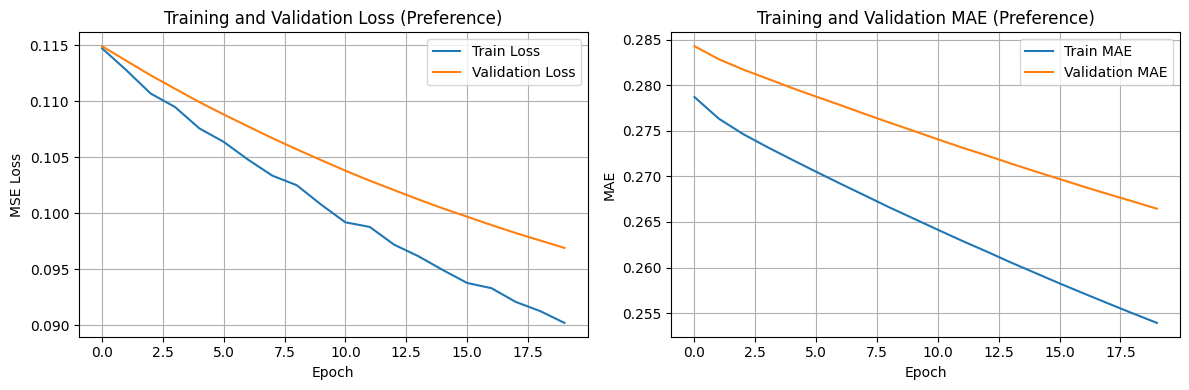

In [36]:
# ====================
# Plot Training History
# ====================
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Plot loss (preference output)
plt.subplot(1, 2, 1)
plt.plot(history.history['preference_output_loss'], label='Train Loss')
plt.plot(history.history['val_preference_output_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss (Preference)')
plt.legend()
plt.grid(True)

# Plot MAE (preference output)
plt.subplot(1, 2, 2)
plt.plot(history.history['preference_output_mae'], label='Train MAE')
plt.plot(history.history['val_preference_output_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Training and Validation MAE (Preference)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# ===========================
# Evaluate on Test Data
# ===========================
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Evaluate preference output only
pref_pred, exposure_pred = model.predict(X_test, verbose=1)
pref_pred = pref_pred.flatten()

mse = mean_squared_error(y_test, pref_pred)
mae = mean_absolute_error(y_test, pref_pred)
rmse = np.sqrt(mse)

print("\n" + "="*50)
print("MODEL EVALUATION METRICS")
print("="*50)
print(f"Test Loss (MSE): {mse:.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print("="*50)

# Save metrics to file
import os
os.makedirs("../results", exist_ok=True)

metrics_text = (
    f"ExpoMF Model Evaluation - Coat Dataset\n"
    f"=====================================\n"
    f"Test Loss (MSE): {mse:.4f}\n"
    f"Test MAE: {mae:.4f}\n"
    f"Test RMSE: {rmse:.4f}\n"
    f"\n"
    f"Dataset Info:\n"
    f"- Total users: {num_users}\n"
    f"- Total items: {num_items}\n"
    f"- Training samples: {len(train_df)}\n"
    f"- Test samples: {len(test_df)}\n"
    f"- Embedding size: {embedding_size}\n"
)

with open("../results/metrics_expomf_coat.txt", "w") as f:
    f.write(metrics_text)

print("\nMetrics saved to: ../results/metrics_expomf_coat.txt")


46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

MODEL EVALUATION METRICS
Test Loss (MSE): 0.0971
Test MAE: 0.2665
Test RMSE: 0.3117

Metrics saved to: ../results/metrics_expomf_coat.txt


Learned Exposure Probabilities:
Mean exposure prob: 0.0153
Min exposure prob: 0.0153
Max exposure prob: 0.0230
Std exposure prob: 0.0004

Initial (popularity-based) exposure:
Mean: 0.0100
Min: 0.0100
Max: 0.0151


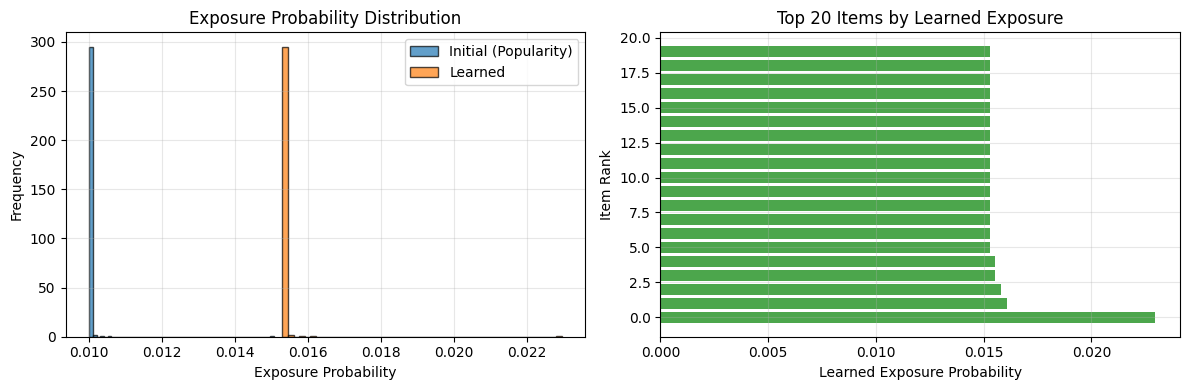


Insight: ExpoMF learns exposure probabilities that may differ from simple popularity.


In [38]:
# ===============
# Analyze Exposure Probabilities
# ===============
# Extract learned exposure probabilities from the model
exposure_layer = model.get_layer('exposure_logit')
exposure_weights = exposure_layer.get_weights()[0].flatten()
learned_exposure_probs = 1 / (1 + np.exp(-exposure_weights))  # Sigmoid inverse

print("Learned Exposure Probabilities:")
print("="*50)
print(f"Mean exposure prob: {learned_exposure_probs.mean():.4f}")
print(f"Min exposure prob: {learned_exposure_probs.min():.4f}")
print(f"Max exposure prob: {learned_exposure_probs.max():.4f}")
print(f"Std exposure prob: {learned_exposure_probs.std():.4f}")

# Compare with initial (popularity-based) exposure
print(f"\nInitial (popularity-based) exposure:")
print(f"Mean: {exposure_probs_array.mean():.4f}")
print(f"Min: {exposure_probs_array.min():.4f}")
print(f"Max: {exposure_probs_array.max():.4f}")

# Visualize exposure probabilities
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(exposure_probs_array, bins=50, alpha=0.7, label='Initial (Popularity)', edgecolor='black')
plt.hist(learned_exposure_probs, bins=50, alpha=0.7, label='Learned', edgecolor='black')
plt.xlabel('Exposure Probability')
plt.ylabel('Frequency')
plt.title('Exposure Probability Distribution')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Top 20 items by learned exposure
top_exposed_items = np.argsort(learned_exposure_probs)[::-1][:20]
top_exposure_values = learned_exposure_probs[top_exposed_items]
plt.barh(range(len(top_exposed_items)), top_exposure_values, alpha=0.7, color='green')
plt.ylabel('Item Rank')
plt.xlabel('Learned Exposure Probability')
plt.title('Top 20 Items by Learned Exposure')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInsight: ExpoMF learns exposure probabilities that may differ from simple popularity.")


In [39]:
# ===============
# Test Prediction
# ===============
# Let's predict rating for a specific user-item pair

# Get a random user and item from the test set
sample_idx = np.random.randint(0, len(test_df))
sample_row = test_df.iloc[sample_idx]

user_id_original = sample_row['userId']
item_id_original = sample_row['itemId']
actual_rating = sample_row['rating']

user_enc = user2user_encoded[user_id_original]
item_enc = item2item_encoded[item_id_original]

# Predict (preference output is first)
pref_pred, exp_pred = model.predict([np.array([user_enc]), np.array([item_enc])], verbose=0)
pred_scaled = pref_pred[0][0]

# Get exposure probability for this item
exposure_prob_item = exp_pred[0][0]

# Convert back to original rating scale
pred_original = scaler.inverse_transform([[pred_scaled]])[0][0]
actual_original = scaler.inverse_transform([[actual_rating]])[0][0]

print("Sample Prediction:")
print("="*50)
print(f"User ID: {user_id_original}")
print(f"Item ID: {item_id_original}")
print(f"\nActual rating (scaled 0-1): {actual_rating:.3f}")
print(f"Predicted rating (scaled 0-1): {pred_scaled:.3f}")
print(f"Exposure probability for this item: {exposure_prob_item:.4f}")
print(f"\nActual rating (original scale): {actual_original:.2f}")
print(f"Predicted rating (original scale): {pred_original:.2f}")
print(f"\nAbsolute error: {abs(pred_original - actual_original):.2f}")


Sample Prediction:
User ID: 261.0
Item ID: 57.0

Actual rating (scaled 0-1): 0.500
Predicted rating (scaled 0-1): 0.454
Exposure probability for this item: 0.0153

Actual rating (original scale): 3.00
Predicted rating (original scale): 2.82

Absolute error: 0.18


In [40]:
# ===============
# Recommender Function with Exposure Awareness
# ===============
def recommend_items_expomf(user_id_original, model, user2user_encoded, item2item_encoded, 
                           itemencoded2item, train_df, num_items, learned_exposure_probs, top_n=10):
    """
    Recommend top N items for a given user using ExpoMF
    Accounts for both preference and exposure probability
    """
    # Check if user exists
    if user_id_original not in user2user_encoded:
        print(f"User {user_id_original} not found in the dataset!")
        return []
    
    # Encode user
    user_enc = user2user_encoded[user_id_original]
    
    # All encoded items
    all_item_ids = np.arange(num_items)
    
    # Items the user has already rated in training
    items_rated = train_df[train_df['user'] == user_enc]['item'].values
    
    # Candidate items (unseen by user)
    items_to_predict = np.setdiff1d(all_item_ids, items_rated)
    
    if len(items_to_predict) == 0:
        print(f"User {user_id_original} has already rated all items!")
        return []
    
    # Prepare input arrays
    user_array = np.full(len(items_to_predict), user_enc)
    
    # Predict preference and exposure scores
    pref_preds, exp_preds = model.predict([user_array, items_to_predict], verbose=0)
    preds = pref_preds.flatten()
    exposure_probs_candidates = exp_preds.flatten()
    
    # Combined score: preference × exposure (items with higher exposure are more likely to be recommended)
    # But we want to balance: high preference AND reasonable exposure
    combined_scores = preds * exposure_probs_candidates
    
    # Sort by combined score
    top_indices = items_to_predict[np.argsort(combined_scores)[::-1][:top_n]]
    top_scores = preds[np.argsort(combined_scores)[::-1][:top_n]]
    top_exposure = exposure_probs_candidates[np.argsort(combined_scores)[::-1][:top_n]]
    
    # Map back to original item IDs
    recommendations = []
    for item_enc, score, exposure_prob in zip(top_indices, top_scores, top_exposure):
        item_id_original = itemencoded2item[item_enc]
        # Convert score back to original scale
        score_original = scaler.inverse_transform([[score]])[0][0]
        recommendations.append((item_id_original, score, score_original, exposure_prob))
    
    return recommendations

print("ExpoMF Recommender function defined!")


ExpoMF Recommender function defined!


In [41]:
# ===============================
# Generate Recommendations
# ===============================
# Let's get recommendations for a random user

# Pick a random user from the dataset
sample_user = np.random.choice(list(user2user_encoded.keys()))

print(f"Generating recommendations for User {sample_user}")
print("="*50)

# Get user's existing ratings from training set
user_enc = user2user_encoded[sample_user]
user_history = train_df[train_df['user'] == user_enc][['itemId', 'rating']].head(10)

print(f"\nUser {sample_user}'s rating history (sample):")
if len(user_history) > 0:
    for idx, row in user_history.iterrows():
        rating_original = scaler.inverse_transform([[row['rating']]])[0][0]
        print(f"  Item {row['itemId']}: Rating {rating_original:.2f}")
else:
    print("  No rating history in training set")

# Generate recommendations
recommendations = recommend_items_expomf(
    user_id_original=sample_user,
    model=model,
    user2user_encoded=user2user_encoded,
    item2item_encoded=item2item_encoded,
    itemencoded2item=itemencoded2item,
    train_df=train_df,
    num_items=num_items,
    learned_exposure_probs=learned_exposure_probs,
    top_n=10
)

print(f"\nTop 10 Recommended Items for User {sample_user}:")
print("="*70)
print(f"{'Rank':<6} {'Item':<8} {'Pred Rating':<12} {'Exposure Prob':<15} {'Combined Score':<15}")
print("-" * 70)
for i, (item_id, score_scaled, score_original, exposure_prob) in enumerate(recommendations, 1):
    combined = score_scaled * exposure_prob
    print(f"{i:<6} {item_id:<8} {score_original:<12.2f} {exposure_prob:<15.4f} {combined:<15.4f}")


Generating recommendations for User 258

User 258's rating history (sample):
  Item 64.0: Rating 3.00
  Item 192.0: Rating 1.00
  Item 2.0: Rating 4.00
  Item 215.0: Rating 1.00
  Item 124.0: Rating 2.00
  Item 78.0: Rating 2.00
  Item 175.0: Rating 1.00
  Item 6.0: Rating 3.00
  Item 247.0: Rating 1.00
  Item 29.0: Rating 2.00

Top 10 Recommended Items for User 258:
Rank   Item     Pred Rating  Exposure Prob   Combined Score 
----------------------------------------------------------------------
1      0        3.13         0.0230          0.0122         
2      252      3.05         0.0153          0.0078         
3      120      3.01         0.0153          0.0077         
4      62       2.93         0.0153          0.0074         
5      193      2.91         0.0153          0.0073         
6      297      2.90         0.0153          0.0073         
7      114      2.87         0.0153          0.0071         
8      147      2.86         0.0153          0.0071         
9      80 

In [ ]:
# ===============================
# Model Summary and Information
# ===============================
print("\n" + "="*60)
print("EXPOMF MODEL SUMMARY")
print("="*60)
print(f"Dataset: Coat Data")
print(f"Total Users: {num_users}")
print(f"Total Items: {num_items}")
print(f"Total Interactions: {len(ratings)}")
print(f"\nTraining Samples: {len(train_df)}")
print(f"Test Samples: {len(test_df)}")
print(f"\nEmbedding Size: {embedding_size}")
print(f"Regularization Strength: {reg_strength}")
print(f"\nTest MSE: {mse:.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"\nMean Learned Exposure Probability: {learned_exposure_probs.mean():.4f}")
print("="*60)
print("\nModel saved as: expomf_coat_best_model.keras")
print("Metrics saved as: ../results/metrics_expomf_coat.txt")
print("\nKey Feature: ExpoMF explicitly models exposure bias by learning")
print("exposure probabilities for each item, distinguishing between lack of")
print("exposure and lack of preference.")



EXPOMF MODEL SUMMARY
Dataset: Coat Data
Total Users: 290
Total Items: 300
Total Interactions: 6960

Training Samples: 5510
Test Samples: 1450

Embedding Size: 32
Regularization Strength: 0.01

Test MSE: 0.0971
Test MAE: 0.2665
Test RMSE: 0.3117

Mean Learned Exposure Probability: 0.0153

Model saved as: expomf_coat_best_model.keras
Metrics saved as: ../results/metrics_expomf_coat.txt

Key Feature: ExpoMF explicitly models exposure bias by learning
exposure probabilities for each item, distinguishing between lack of
exposure and lack of preference.
